Mandatory Assigment 2 - Bysykkel Station Popularity

Usecase: We want to predict whether an Oslo Bysykkel station has Low, Medium, or High popularity.

We chose Logistic Regression because the output has three categories: Low, Medium, and High.
This makes the problem a classification problem.
Logistic Regression is a simple classification algorithm that we have used in the labs.
We use station usage data such as trips started, trips ended, and average trip duration to predict the popularity category.

In [203]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [204]:
df = pd.read_csv('data/Bysykkel_09.csv')
df.head()

,started_at,ended_at,duration,start_station_id,start_station_name,start_station_description,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_description,end_station_latitude,end_station_longitude
0,2025-09-01 03:00:58.648000+00:00,2025-09-01 03:10:55.808000+00:00,597,597,Fredensborg,ved rundkjøringen,59.920995,10.750358,435,Fram-gården,langs Bygdøy Allé,59.915424,10.714577
1,2025-09-01 03:05:24.230000+00:00,2025-09-01 03:08:38.433000+00:00,194,2339,Elgsletta,langs Nylandsveien,59.915649,10.761725,2328,The Hub,mellom Oslo City og The Hub hotel,59.912472,10.750847
2,2025-09-01 03:10:37.948000+00:00,2025-09-01 03:28:34.696000+00:00,1076,620,Bislettgata,ved Sofies Gate,59.923774,10.734713,512,Ensjø T-bane,langs Ensjøveien,59.913189,10.789760
3,2025-09-01 03:14:15.891000+00:00,2025-09-01 03:19:03.853000+00:00,287,746,Bygdøy allé,ved parkeringsplassen,59.919001,10.692321,572,Skøyen,under broen,59.922269,10.679580
4,2025-09-01 03:21:02.841000+00:00,2025-09-01 03:40:02.621000+00:00,1139,422,St. Hanshaugen,langs Waldemar Thranes gate,59.923703,10.740542,484,Karenslyst allé,ved Skabos vei,59.920330,10.683814


In [205]:
print("Number of trips:", len(df))
print("Number of columns:", len(df.columns))
print()
df.info()

Number of trips: 138416
Number of columns: 13

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138416 entries, 0 to 138415
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   started_at                 138416 non-null  object 
 1   ended_at                   138416 non-null  object 
 2   duration                   138416 non-null  int64  
 3   start_station_id           138416 non-null  int64  
 4   start_station_name         138416 non-null  object 
 5   start_station_description  138416 non-null  object 
 6   start_station_latitude     138416 non-null  float64
 7   start_station_longitude    138416 non-null  float64
 8   end_station_id             138416 non-null  int64  
 9   end_station_name           138416 non-null  object 
 10  end_station_description    138416 non-null  object 
 11  end_station_latitude       138416 non-null  float64
 12  end_station_longitude      138416 non-n

In [206]:
df.describe()

,duration,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude
count,138416.000000,138416.000000,138416.000000,138416.000000,138416.000000,138416.000000,138416.000000
mean,706.317218,722.081949,59.921921,10.747182,730.553122,59.919347,10.745752
std,726.083265,756.137167,0.010602,0.023983,746.867857,0.009616,0.022594
min,61.000000,377.000000,59.898440,10.651118,377.000000,59.898440,10.651118
25%,363.000000,436.000000,59.913233,10.730589,440.000000,59.912111,10.731219
50%,548.000000,501.000000,59.920404,10.750775,499.000000,59.917281,10.750358
75%,809.000000,590.000000,59.928434,10.762169,590.000000,59.925471,10.760804
max,16766.000000,5431.000000,59.953411,10.814314,5431.000000,59.953411,10.814314


3. Prepare station-level data
The original dataset contains one row for each bike trip.
For this assignment we need one row for each station, so we group the trips by station and calculate:
total_trips_started
total_trips_ended
avg_duration
The average duration is calculated from trips that started at each station.

In [207]:
# Count trips that started at each station and calculate average trip duration
started = (
    df.groupby(['start_station_id', 'start_station_name'])
      .agg(
          total_trips_started=('start_station_id', 'size'),
          avg_duration=('duration', 'mean')
      )
      .reset_index()
      .rename(columns={
          'start_station_id': 'station_id',
          'start_station_name': 'station_name'
      })
)

# Count trips that ended at each station
ended = (
    df.groupby('end_station_id')
      .size()
      .reset_index(name='total_trips_ended')
      .rename(columns={'end_station_id': 'station_id'})
)

# Merge the two tables
station_data = started.merge(ended, on='station_id', how='outer')

# Replace missing trip counts with 0
station_data[['total_trips_started', 'total_trips_ended']] = (
    station_data[['total_trips_started', 'total_trips_ended']].fillna(0)
)

# Remove rows where average duration/name is missing
station_data = station_data.dropna(subset=['station_name', 'avg_duration']).copy()

station_data.head()

,station_id,station_name,total_trips_started,avg_duration,total_trips_ended
0,377,Tøyenparken,337,710.513353,297
1,380,Bentsebrugata,1103,748.097915,463
2,381,Grønlands torg,607,734.202636,691
3,382,Stensgata,313,679.910543,294
4,383,Arkitekt Rivertz Plass,880,651.603409,391


In [208]:
print("Number of stations:", len(station_data))
station_data[['total_trips_started', 'total_trips_ended', 'avg_duration']].describe()

Number of stations: 267


,total_trips_started,total_trips_ended,avg_duration
count,267.000000,267.000000,267.000000
mean,518.411985,518.411985,744.345455
std,322.910581,411.452473,206.317824
min,30.000000,12.000000,478.423701
25%,306.500000,248.500000,620.378171
50%,465.000000,396.000000,696.710900
75%,639.000000,670.500000,796.532152
max,1769.000000,2263.000000,2139.766990


4. Create the target variable
The assignment defines station popularity from total station usage:
total_usage = total_trips_started + total_trips_ended
We divide all stations into three equally sized groups:
Low = bottom 33%
Medium = middle 33%
High = top 33%
pd.qcut() is useful here because it divides the stations into groups containing approximately the same number of stations.

In [209]:
station_data['total_usage'] = (
    station_data['total_trips_started'] + station_data['total_trips_ended']
)

station_data['popularity'] = pd.qcut(
    station_data['total_usage'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

station_data[['station_name', 'total_trips_started', 'total_trips_ended',
              'avg_duration', 'total_usage', 'popularity']].head(10)

,station_name,total_trips_started,total_trips_ended,avg_duration,total_usage,popularity
0,Tøyenparken,337,297,710.513353,634,Low
1,Bentsebrugata,1103,463,748.097915,1566,High
2,Grønlands torg,607,691,734.202636,1298,High
3,Stensgata,313,294,679.910543,607,Low
4,Arkitekt Rivertz Plass,880,391,651.603409,1271,High
5,Vår Frelsers gravlund,1563,1567,555.184901,3130,High
6,Studenterlunden,374,379,874.719251,753,Medium
7,Skovveien,514,510,824.881323,1024,Medium
8,Pilestredet Studenthus,279,262,617.243728,541,Low
9,Saga Kino,656,1007,614.114329,1663,High


In [210]:
# Check how many stations are in each category
station_data['popularity'].value_counts().sort_index()

popularity
Low       89
Medium    89
High      89
Name: count, dtype: int64

In [211]:
# Show the usage range for each category
station_data.groupby('popularity', observed=True)['total_usage'].agg(['min', 'max', 'count'])

,min,max,count
popularity,,,
Low,58,664,89
Medium,669,1122,89
High,1140,3905,89


Visualize the popularity groups

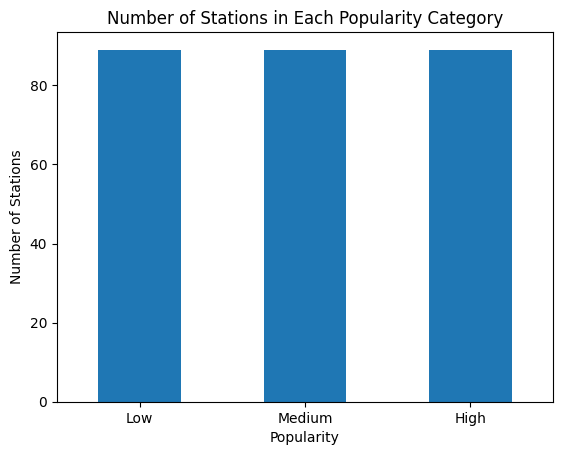

In [212]:
station_data['popularity'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Stations in Each Popularity Category')
plt.xlabel('Popularity')
plt.ylabel('Number of Stations')
plt.xticks(rotation=0)
plt.show()

5. Prepare training and test data
X contains the input features and y contains the category we want to predict.
We use 80% of the stations to train the model and 20% to test it. random_state=42 makes the split reproducible. stratify=y keeps the three popularity classes balanced in both sets.

In [213]:
features = ['total_trips_started', 'total_trips_ended', 'avg_duration']

X = station_data[features]
y = station_data['popularity']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))


Training rows: 213
Test rows: 54


6. Train the Logistic Regression model

In [214]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

7. Make predictions

In [215]:
y_pred = model.predict(X_test)

In [216]:
# Show the first few predicted and actual values
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

results.head(10)

,Actual,Predicted
0,Low,Low
1,High,High
2,Medium,Medium
3,Low,Low
4,Low,Low
5,Medium,Medium
6,Medium,Medium
7,Low,Low
8,High,High
9,Medium,Medium


8. Accuracy score

In [217]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(f"Accuracy percentage: {accuracy * 100:.1f}%")

Accuracy: 1.00
Accuracy percentage: 100.0%


Accuracy result: 
Accuracy tells us how many of the test stations were placed in the correct popularity category.
A very high accuracy is expected in this particular task because the popularity category is created directly from total trips started and ended, and these counts are also used as input features for the model.

9. Confusion matrix

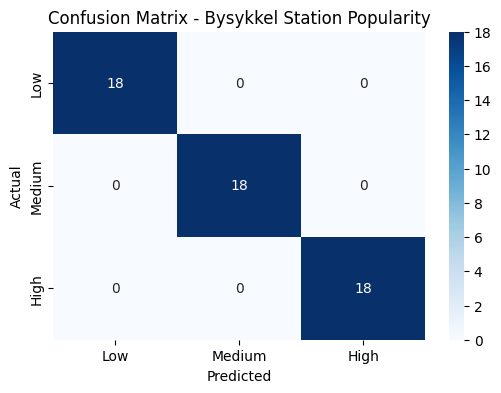

In [218]:
labels = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Bysykkel Station Popularity')
plt.show()

The confusion matrix compares the real category with the category predicted by the model.
Values on the diagonal are correct predictions, while values outside the diagonal are incorrect predictions.

10. Classification report

In [219]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        18
         Low       1.00      1.00      1.00        18
      Medium       1.00      1.00      1.00        18

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



11. Example prediction

In [220]:
# Select one station as an example
example_station = station_data.iloc[[0]]

example_features = example_station[features]
prediction = model.predict(example_features)[0]

print("Station:", example_station['station_name'].iloc[0])
print("Trips started:", int(example_station['total_trips_started'].iloc[0]))
print("Trips ended:", int(example_station['total_trips_ended'].iloc[0]))
print("Average duration:", round(example_station['avg_duration'].iloc[0], 2), "seconds")
print("Predicted popularity:", prediction)
print("Actual popularity:", example_station['popularity'].iloc[0])

Station: Tøyenparken
Trips started: 337
Trips ended: 297
Average duration: 710.51 seconds
Predicted popularity: Low
Actual popularity: Low


Conclusion: 
We used September 2025 Oslo Bysykkel trip data to create station-level usage features and divided the stations into Low, Medium, and High popularity groups.
A Logistic Regression classification model was trained using trips started, trips ended, and average trip duration.
The model achieved a high accuracy and the confusion matrix shows how the predicted categories compare with the real categories.
The result is especially strong because the popularity target is directly based on the same trip-count features used by the model, so the task is intentionally simple and follows the assignment specification.